## Validate best params on the full 10-fold CV

Same splitter / seed as the canonical model notebook so the score is directly comparable. After this finishes, paste `study.best_params` into the canonical notebook and re-run it — that produces the OOF/test CSVs the blender consumes.

## Imports

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import lightgbm as lgb
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

from common import *

print('lightgbm:', lgb.__version__)
print('optuna:  ', optuna.__version__)

lightgbm: 4.6.0
optuna:   4.8.0


## Load + preprocess (mirror of `lightgbm.ipynb`)

In [2]:
train_df = pd.read_csv('archive/train.csv')
test_df  = pd.read_csv('archive/test.csv')
orig_df  = pd.read_csv('archive/f1_strategy_dataset_v4.csv')

df = (train_df
        .pipe(copy_data)
        .pipe(clean_data)
        .pipe(remove_duplicates)
        .pipe(make_new_features))

orig_df_cleaned = (orig_df
        .pipe(copy_data)
        .pipe(clean_data)
        .pipe(remove_duplicates)
        .pipe(make_new_features))

train_df_length = df.shape[0]
df = pd.concat([df, orig_df_cleaned])
if 'normalized_tyrelife' in df.columns:
    df = df.drop('normalized_tyrelife', axis=1)
df = df.reset_index(drop=True)

sample_weights = np.ones(df.shape[0])
sample_weights[train_df_length:] = 1.25

target = get_target()
features = get_features(df)
categorical_features = ['compound', 'race', 'year_cat']
df[categorical_features] = df[categorical_features].astype('category')

X, y = df[features], df[target]
groups = (df['race'].astype(str) + '_' + df['year'].astype(str)).values
strat_y = (df['pitnextlap'].astype(str) + '_' + df['year'].astype(str))

print(df.shape, 'rows /', len(features), 'features')
print('positive rate:', y.mean().round(4))

(540511, 15) rows / 14 features
positive rate: 0.2094


## Optuna objective

5-fold search, TPE sampler with MedianPruner. We report the running mean AUC after each fold so pruning can kill bad trials before all folds run.

In [3]:
TUNE_N_SPLITS = 5
SEED = 42

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'n_estimators': 3000,
        'n_jobs': -1,
        'random_state': 123,
        'verbose': -1,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 16, 255),
        'max_depth':         trial.suggest_int('max_depth', 4, 14),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 200),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha',  1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    sgkf = StratifiedGroupKFold(n_splits=TUNE_N_SPLITS, shuffle=True, random_state=123)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, strat_y, groups=groups)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
            sample_weight=sample_weights[tr_idx],
            categorical_feature=categorical_features,
        )
        proba = model.predict_proba(X_val)[:, 1]
        fold_scores.append(roc_auc_score(y_val, proba))

        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

## Run the study

Trial 0 = the current baseline params so we have a known anchor and can never go backwards. The cell respects `N_TRIALS` and a wall-clock timeout — adjust either knob and re-run.

In [4]:
N_TRIALS = 60
TIMEOUT_SEC = 60 * 60 * 4   # 4 hours cap

# Enqueue the current LB-validated baseline as trial 0
baseline_params = {
    'learning_rate':     0.1,
    'num_leaves':        31,
    'max_depth':         -1 if False else 8,
    'min_child_samples': 20,
    'feature_fraction':  1.0,
    'bagging_fraction':  1.0,
    'bagging_freq':      1,
    'reg_alpha':         1e-8,
    'reg_lambda':        1e-8,
    'min_split_gain':    0.0,
}

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    study_name='lgbm_f1_pit',
)
study.enqueue_trial(baseline_params)
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SEC, show_progress_bar=True, gc_after_trial=True)

print('best AUC (5-fold):', round(study.best_value, 5))
print('best params:', study.best_params)

[I 2026-05-27 22:08:52,762] A new study created in memory with name: lgbm_f1_pit


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-27 22:09:27,062] Trial 0 finished with value: 0.9242984591381779 and parameters: {'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 20, 'feature_fraction': 1.0, 'bagging_fraction': 1.0, 'bagging_freq': 1, 'reg_alpha': 1e-08, 'reg_lambda': 1e-08, 'min_split_gain': 0.0}. Best is trial 0 with value: 0.9242984591381779.
[I 2026-05-27 22:11:19,789] Trial 1 finished with value: 0.9288570444947689 and parameters: {'learning_rate': 0.02757359293934948, 'num_leaves': 244, 'max_depth': 12, 'min_child_samples': 122, 'feature_fraction': 0.5780093202212182, 'bagging_fraction': 0.5779972601681014, 'bagging_freq': 1, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'min_split_gain': 0.7080725777960455}. Best is trial 1 with value: 0.9288570444947689.
[I 2026-05-27 22:15:48,482] Trial 2 finished with value: 0.9296921482863141 and parameters: {'learning_rate': 0.010573268083515799, 'num_leaves': 248, 'max_depth': 13, 'min_child_samples': 46, 'fe

## Study summary

In [5]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params', 'duration'))
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.head(15)

,number,value,state,params_bagging_fraction,params_bagging_freq,params_feature_fraction,params_learning_rate,params_max_depth,params_min_child_samples,params_min_split_gain,params_num_leaves,params_reg_alpha,params_reg_lambda,duration
48,48,0.930352,COMPLETE,0.876461,2,0.511791,0.010242,13,48,0.033614,213,0.178574,4.530971e-07,0 days 00:06:12.237146
49,49,0.930320,COMPLETE,0.951530,4,0.566664,0.011947,14,137,0.034158,213,0.395651,4.473978e-07,0 days 00:05:03.015148
22,22,0.930267,COMPLETE,0.742901,4,0.514946,0.020515,14,73,0.069945,231,0.002140,4.515072e-01,0 days 00:03:04.580734
57,57,0.930169,COMPLETE,0.827512,3,0.528442,0.014041,14,100,0.064298,244,0.000008,1.039101e+00,0 days 00:04:03.756868
42,42,0.930124,COMPLETE,0.887279,2,0.503139,0.011337,11,80,0.054137,186,0.053355,3.394814e-05,0 days 00:04:38.213422
40,40,0.930116,COMPLETE,0.748691,2,0.536908,0.018539,14,132,0.063062,254,0.000665,1.335513e+00,0 days 00:03:34.488618
30,30,0.930012,COMPLETE,0.862309,2,0.523787,0.015345,12,93,0.069564,195,0.002343,1.729982e-01,0 days 00:03:24.914675
51,51,0.929940,PRUNED,0.977009,2,0.631223,0.011396,12,69,0.013454,235,0.328450,4.356766e-07,0 days 00:03:51.642465
39,39,0.929870,COMPLETE,0.776474,2,0.520393,0.017701,12,67,0.292950,242,0.001857,2.976329e-03,0 days 00:03:00.401081
29,29,0.929858,COMPLETE,0.727741,2,0.544735,0.017981,14,121,0.098694,203,0.001248,2.116007e-02,0 days 00:03:09.892754


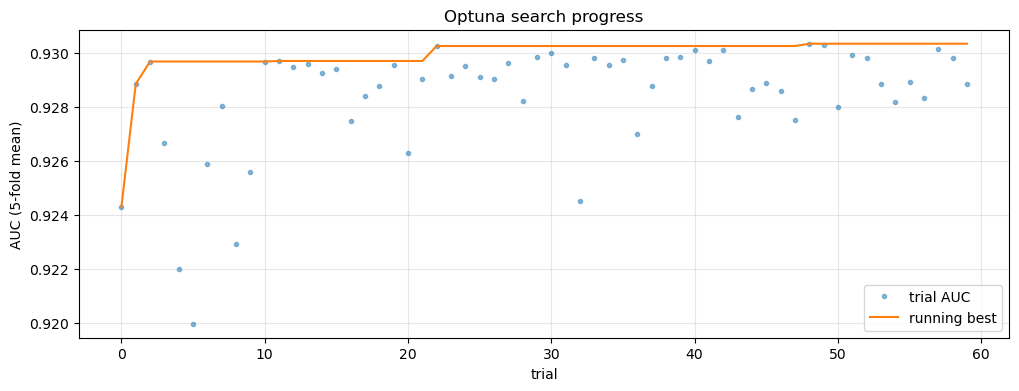

In [9]:
plt.rcParams['figure.figsize'] = (12, 4)

vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(vals)
plt.plot(vals, '.', alpha=0.5, label='trial AUC')
plt.plot(running_best, label='running best')
plt.xlabel('trial')
plt.ylabel('AUC (5-fold mean)')
plt.legend(); plt.grid(alpha=0.3); plt.title('Optuna search progress'); plt.show()

## Validate best params on the full 10-fold CV

Same splitter / seed as `lightgbm.ipynb` so the score is comparable to the 0.92742 baseline.

In [ ]:
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 3000,
    'n_jobs': -1,
    'random_state': 123,
    'verbose': -1,
    **study.best_params,
}

sgkf_full = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=123)
scores, best_iters = [], []
oof_preds = np.zeros(len(df))

for fold, (tr_idx, val_idx) in enumerate(sgkf_full.split(X, strat_y, groups=groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
        sample_weight=sample_weights[tr_idx],
        categorical_feature=categorical_features,
    )
    proba = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = proba
    score = roc_auc_score(y_val, proba)
    scores.append(score)
    best_iters.append(model.best_iteration_)
    print(f'Fold {fold}: AUC={score:.5f}  best_iter={model.best_iteration_}')

print(f'\nMean AUC: {np.mean(scores):.5f} ± {np.std(scores):.5f}')
print(f'Mean best_iter: {int(np.mean(best_iters))}  Max best_iter: {int(np.max(best_iters))}')

oof_train = oof_preds[:train_df_length]
y_train_arr = y.iloc[:train_df_length].values
print(f'OOF AUC (train portion): {roc_auc_score(y_train_arr, oof_train):.5f}')

Fold 0: AUC=0.92083  best_iter=2140


In [ ]:
final_params = {**best_params}
final_params['n_estimators'] = int(np.max(best_iters) * 1.10)

lgbm_final_model = LGBMClassifier(**final_params)
lgbm_final_model.fit(X, y, sample_weight=sample_weights, categorical_feature=categorical_features)
print('trained final model with n_estimators =', final_params['n_estimators'])

In [ ]:
import json
with open('./archive/lgbm_best_params.json', 'w') as f:
    json.dump({
        'best_params': study.best_params,
        'best_value_5fold': study.best_value,
        'mean_auc_10fold': float(np.mean(scores)),
        'std_auc_10fold':  float(np.std(scores)),
        'best_iters': [int(b) for b in best_iters],
    }, f, indent=2)
print('saved ./archive/lgbm_best_params.json')